In [1]:
import pandas as pd

df = pd.read_csv("../data/resumes.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8, 4)


,Name,Experience,Skills,Education
0,Rahul,3,"Python, Machine Learning, SQL, Pandas, Data An...",B.Tech CSE
1,Priya,2,"Java, Spring Boot, MySQL, REST API",B.Tech IT
2,Arjun,4,"Python, Pandas, Excel, Data Analysis, SQL",B.Tech CSE
3,Sneha,5,"Machine Learning, Deep Learning, Python, Tenso...",M.Tech AI
4,Kiran,1,"HTML, CSS, JavaScript, React",B.Tech CSE


In [2]:
import pandas as pd

df = pd.read_csv("../data/Resume Screening.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (962, 2)

Columns:
['Category', 'Resume']


In [3]:
print(df.head())

print("\nCategories:")
print(df['Category'].unique())

print("\nNumber of Categories:", df['Category'].nunique())

       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...

Categories:
<StringArray>
[             'Data Science',                        'HR',
                  'Advocate',                      'Arts',
             'Web Designing',       'Mechanical Engineer',
                     'Sales',        'Health and fitness',
            'Civil Engineer',            'Java Developer',
          'Business Analyst',             'SAP Developer',
        'Automation Testing',    'Electrical Engineering',
        'Operations Manager',          'Python Developer',
           'DevOps Engineer', 'Network Security Engineer',
                       'PMO',           

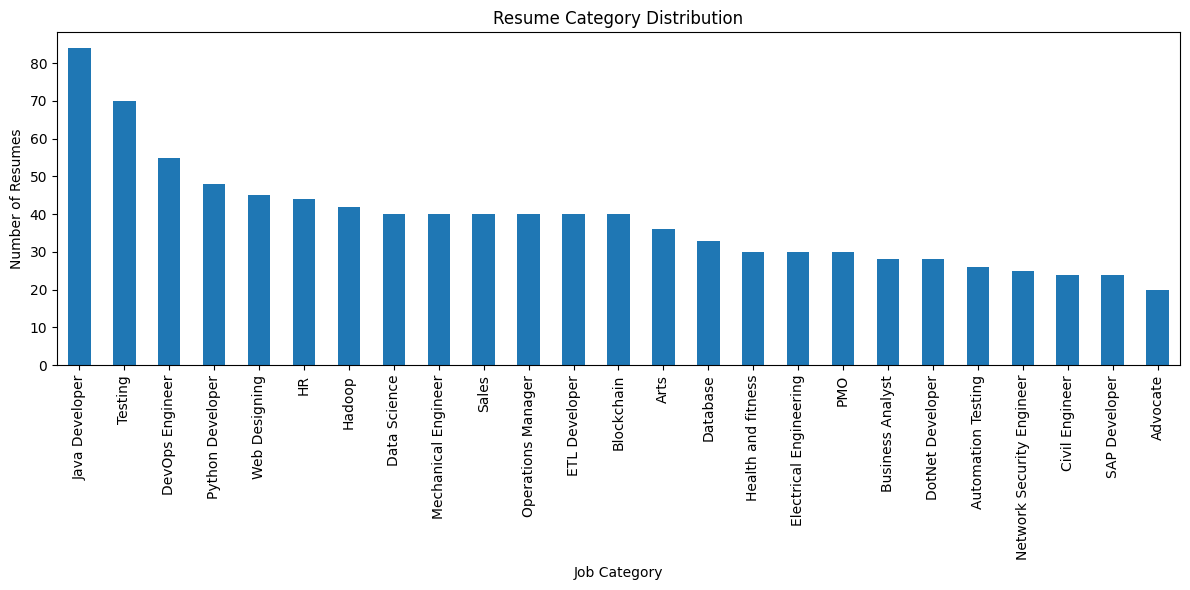

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df['Category'].value_counts().plot(kind='bar')

plt.title("Resume Category Distribution")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [5]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+', ' ', text)          # remove URLs
    text = re.sub(r'www\S+', ' ', text)           # remove websites
    text = re.sub(r'@\S+', ' ', text)             # remove mentions
    text = re.sub(r'[^a-zA-Z ]', ' ', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text)              # remove extra spaces
    return text.lower().strip()

df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)

print(df[['Category', 'Cleaned_Resume']].head())

       Category                                     Cleaned_Resume
0  Data Science  skills programming languages python pandas num...
1  Data Science  education details may to may b e uit rgpv data...
2  Data Science  areas of interest deep learning control system...
3  Data Science  skills r python sap hana tableau sap hana sql ...
4  Data Science  education details mca ymcaust faridabad haryan...


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category_Encoded'] = le.fit_transform(df['Category'])

print(df[['Category', 'Category_Encoded']].head())

       Category  Category_Encoded
0  Data Science                 6
1  Data Science                 6
2  Data Science                 6
3  Data Science                 6
4  Data Science                 6


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['Cleaned_Resume'])

y = df['Category_Encoded']

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (962, 5000)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (769, 5000)
Test Shape: (193, 5000)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9948186528497409


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9896373056994818


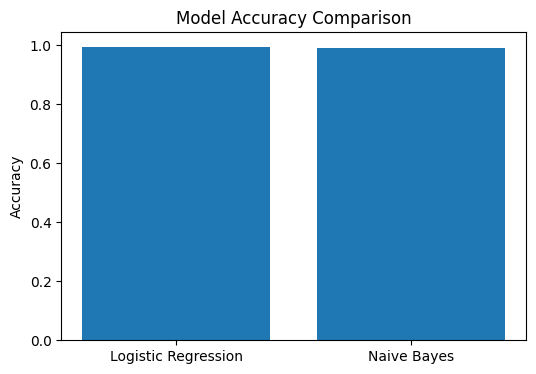

Logistic Regression: 0.9948186528497409
Naive Bayes: 0.9896373056994818


In [11]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Naive Bayes"]
scores = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

print("Logistic Regression:", lr_accuracy)
print("Naive Bayes:", nb_accuracy)

In [12]:
sample_resume = """
Python
Machine Learning
Deep Learning
Pandas
NumPy
SQL
Data Analysis
"""

sample_vector = tfidf.transform([clean_resume(sample_resume)])

prediction = lr_model.predict(sample_vector)

predicted_category = le.inverse_transform(prediction)

print("Predicted Category:", predicted_category[0])

Predicted Category: Data Science
